# Raman Spectroscopy Analysis: N-acetylmuramic acid (NAM)

## WITHOUT NORMALIZATION - Raw Intensities

**Author:** Analysis Notebook  
**Date:** February 10, 2026

### Overview
This notebook performs comprehensive analysis WITHOUT normalization to see raw intensities:
1. **DFT simulated Raman spectrum** of NAM (raw intensities)
2. **Experimental powder Raman spectrum** of NAM (preprocessed but NOT normalized)

### Analysis Pipeline
1. Data loading
2. Spectral range limitation (200–2000 cm⁻¹)
3. Dark subtraction (powder only)
4. Baseline correction (powder only)
5. Savitzky-Golay smoothing (powder only)
6. **NO NORMALIZATION** - Keep raw intensities
7. Visualization and comparison

## 1. Import Required Libraries

In [22]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy.sparse import csc_matrix, eye, diags
from scipy.sparse.linalg import spsolve
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib style for publication-quality plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['lines.linewidth'] = 2

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Excel Data Files

In [23]:
# File paths
simulation_file = r"C:\Users\sukes\Downloads\plottingNAM\simulated-NAM.xlsx"
powder_file = r"C:\Users\sukes\Downloads\plottingNAM\powder5per20sec.xlsx"

# Load simulation data
df_simulation = pd.read_excel(simulation_file, header=None)
df_simulation.columns = ['Raman_shift', 'Intensity']

# Load powder Raman data
df_powder = pd.read_excel(powder_file, header=None)
df_powder.columns = ['Raman_shift', 'Intensity']

print("Simulation data shape:", df_simulation.shape)
print("\nFirst 5 rows of simulation data:")
print(df_simulation.head())

print("\n" + "="*60)
print("Powder data shape:", df_powder.shape)
print("\nFirst 5 rows of powder data:")
print(df_powder.head())

Simulation data shape: (226, 2)

First 5 rows of simulation data:
   Raman_shift  Intensity
0          200   0.011501
1          208   0.030821
2          216   0.082627
3          224   0.079292
4          232   0.081922

Powder data shape: (1156, 2)

First 5 rows of powder data:
   Raman_shift  Intensity
0   200.839101     1330.0
1   202.752477     1332.5
2   204.665129     1335.5
3   206.577055     1328.5
4   208.488256     1330.0


## 3. Limit Spectral Range to 200–2000 cm⁻¹

In [24]:
# Define spectral range
range_min, range_max = 200, 2000

# Filter simulation data
df_simulation_filtered = df_simulation[
    (df_simulation['Raman_shift'] >= range_min) & 
    (df_simulation['Raman_shift'] <= range_max)
].copy()

# Filter powder data
df_powder_filtered = df_powder[
    (df_powder['Raman_shift'] >= range_min) & 
    (df_powder['Raman_shift'] <= range_max)
].copy()

print(f"Simulation data filtered: {len(df_simulation)} → {len(df_simulation_filtered)} points")
print(f"Powder data filtered: {len(df_powder)} → {len(df_powder_filtered)} points")
print(f"\nSpectral range: {range_min}–{range_max} cm⁻¹")

print(f"\nSimulation intensity range: [{df_simulation_filtered['Intensity'].min():.2f}, {df_simulation_filtered['Intensity'].max():.2f}]")
print(f"Powder intensity range (raw): [{df_powder_filtered['Intensity'].min():.2f}, {df_powder_filtered['Intensity'].max():.2f}]")

Simulation data filtered: 226 → 226 points
Powder data filtered: 1156 → 1155 points

Spectral range: 200–2000 cm⁻¹

Simulation intensity range: [0.00, 0.76]
Powder intensity range (raw): [234.00, 1763.00]


## 4. Create Output Folder

In [25]:
# Create output folder for saving figures
import os
output_dir = "figures_no_normalization"
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory created: {output_dir}/")

Output directory created: figures_no_normalization/


## 5. Plot Raw Simulation Spectrum (No Normalization)

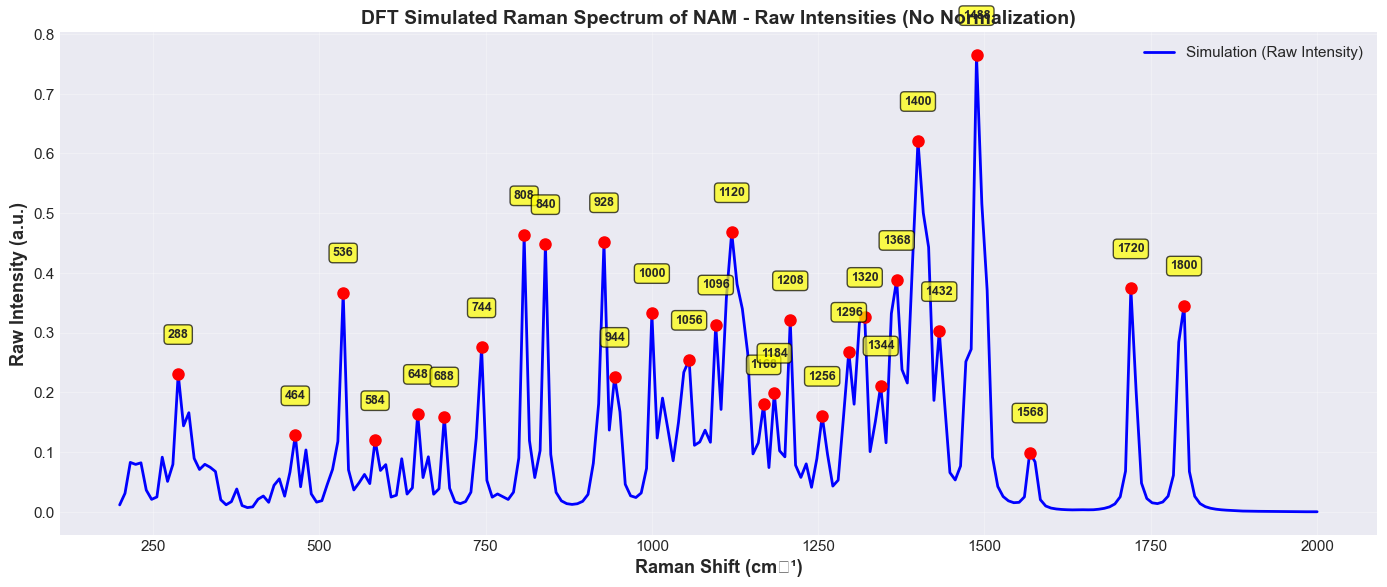

Number of major peaks detected: 29

Peak positions (cm⁻¹): [ 288  464  536  584  648  688  744  808  840  928  944 1000 1056 1096
 1120 1168 1184 1208 1256 1296 1320 1344 1368 1400 1432 1488 1568 1720
 1800]

Intensity range: [0.0000, 0.7646]


In [26]:
# Detect peaks in simulation spectrum (using raw intensities)
peaks_sim, properties_sim = find_peaks(
    df_simulation_filtered['Intensity'].values,
    prominence=0.1 * df_simulation_filtered['Intensity'].max(),  # Scale to raw intensity
    height=0.1 * df_simulation_filtered['Intensity'].max()
)

# Get peak positions and heights
peak_positions_sim = df_simulation_filtered['Raman_shift'].values[peaks_sim]
peak_heights_sim = df_simulation_filtered['Intensity'].values[peaks_sim]

# Plot simulation spectrum with peak annotations
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_simulation_filtered['Raman_shift'], 
        df_simulation_filtered['Intensity'],
        'b-', linewidth=2, label='Simulation (Raw Intensity)')

# Mark and label peaks
for pos, height in zip(peak_positions_sim, peak_heights_sim):
    ax.plot(pos, height, 'ro', markersize=8)
    ax.annotate(f'{pos:.0f}', 
                xy=(pos, height), 
                xytext=(pos, height + 0.08*df_simulation_filtered['Intensity'].max()),
                ha='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=13, fontweight='bold')
ax.set_ylabel('Raw Intensity (a.u.)', fontsize=13, fontweight='bold')
ax.set_title('DFT Simulated Raman Spectrum of NAM - Raw Intensities (No Normalization)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f"{output_dir}/01_simulation_raw_intensities.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Number of major peaks detected: {len(peaks_sim)}")
print("\nPeak positions (cm⁻¹):", peak_positions_sim.round(1))
print(f"\nIntensity range: [{df_simulation_filtered['Intensity'].min():.4f}, {df_simulation_filtered['Intensity'].max():.4f}]")

## 6. Preprocess Powder Data - WITHOUT Normalization

**Preprocessing steps (NO NORMALIZATION):**
1. Dark subtraction (subtract minimum intensity)
2. Baseline correction using ALS
3. Savitzky-Golay smoothing
4. ❌ **NO NORMALIZATION** - Keep raw intensities!

In [27]:
def als_baseline(y, lam=1e5, p=0.01, niter=10):
    """
    Asymmetric Least Squares (ALS) baseline correction
    
    Parameters:
    - y: signal
    - lam: smoothness parameter (larger = smoother baseline)
    - p: asymmetry parameter (0 < p < 1, smaller = more baseline)
    - niter: number of iterations
    
    Returns:
    - z: estimated baseline
    """
    from scipy import sparse
    from scipy.sparse.linalg import spsolve
    
    L = len(y)
    D = sparse.diags([1, -2, 1], [0, -1, -2], shape=(L, L-2))
    w = np.ones(L)
    for _ in range(niter):
        W = sparse.spdiags(w, 0, L, L)
        Z = W + lam * D @ D.T
        z = spsolve(Z, w * y)
        w = p * (y > z) + (1 - p) * (y < z)
    return z

# Copy powder data for processing
df_powder_processed = df_powder_filtered.copy()

# Step 1: Dark subtraction (subtract minimum intensity as dark baseline)
dark_baseline = df_powder_processed['Intensity'].min()
df_powder_processed['Intensity'] = df_powder_processed['Intensity'] - dark_baseline
print(f"Step 1: Dark subtraction completed (baseline = {dark_baseline:.2f})")
print(f"  After dark subtraction: [{df_powder_processed['Intensity'].min():.2f}, {df_powder_processed['Intensity'].max():.2f}]")

# Step 2: Baseline correction using ALS
baseline = als_baseline(df_powder_processed['Intensity'].values, lam=1e5, p=0.01)
df_powder_processed['Intensity'] = df_powder_processed['Intensity'].values - baseline
# Ensure no negative values
df_powder_processed['Intensity'] = np.maximum(df_powder_processed['Intensity'], 0)
print("Step 2: ALS baseline correction completed")
print(f"  After baseline correction: [{df_powder_processed['Intensity'].min():.2f}, {df_powder_processed['Intensity'].max():.2f}]")

# Step 3: Savitzky-Golay smoothing
window_length = 11  # Must be odd
polyorder = 3
df_powder_processed['Intensity'] = savgol_filter(
    df_powder_processed['Intensity'].values, 
    window_length, 
    polyorder
)
print(f"Step 3: Savitzky-Golay smoothing completed (window={window_length}, order={polyorder})")
print(f"  After smoothing: [{df_powder_processed['Intensity'].min():.2f}, {df_powder_processed['Intensity'].max():.2f}]")

print("\n" + "="*70)
print("✓ Step 4: NORMALIZATION SKIPPED - Keeping raw intensities!")
print("="*70)
print(f"\nFinal raw intensity range: [{df_powder_processed['Intensity'].min():.2f}, {df_powder_processed['Intensity'].max():.2f}]")

Step 1: Dark subtraction completed (baseline = 234.00)
  After dark subtraction: [0.00, 1529.00]
Step 2: ALS baseline correction completed
  After baseline correction: [0.00, 748.87]
Step 3: Savitzky-Golay smoothing completed (window=11, order=3)
  After smoothing: [-6.71, 577.06]

✓ Step 4: NORMALIZATION SKIPPED - Keeping raw intensities!

Final raw intensity range: [-6.71, 577.06]


## 7. Plot Preprocessed Powder Spectrum (No Normalization)

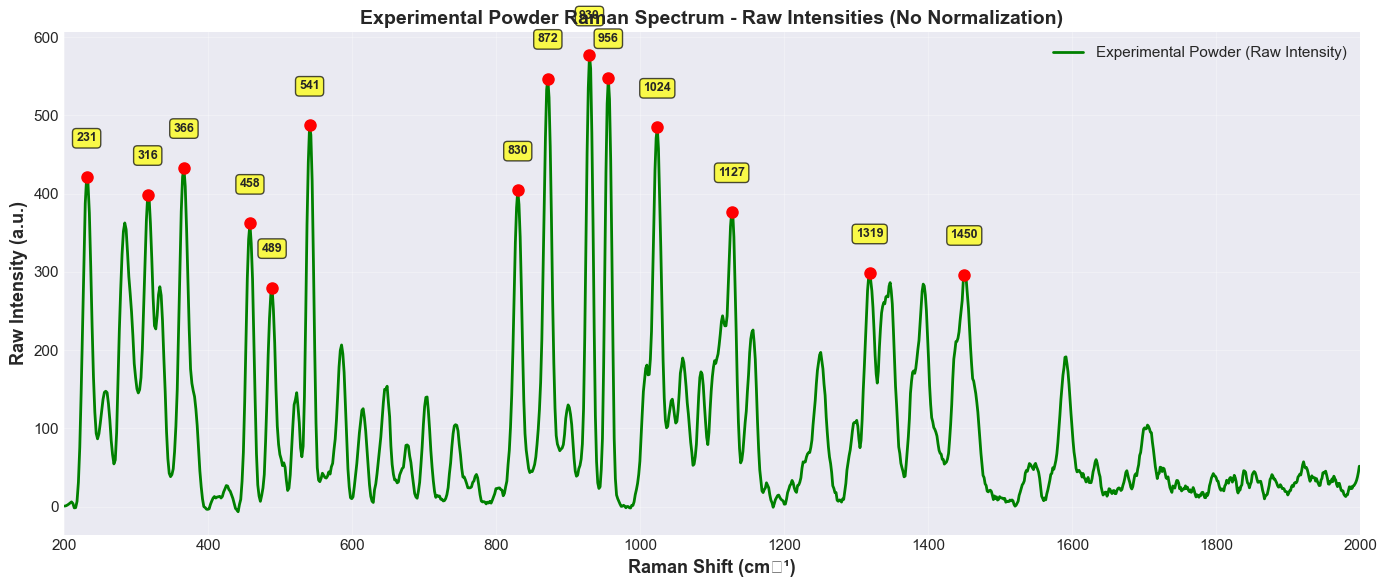

Number of major peaks detected: 14

Peak positions (cm⁻¹): [ 231.4  316.2  366.5  458.2  489.   541.   830.2  871.9  929.8  955.9
 1024.  1127.2 1319.  1450.3]

Intensity range: [-6.71, 577.06]


In [28]:
# Detect peaks in powder spectrum (HIGH INTENSITY ONLY)
intensity_max = df_powder_processed['Intensity'].max()
peaks_powder, properties_powder = find_peaks(
    df_powder_processed['Intensity'].values,
    prominence=0.4 * intensity_max,  # Only HIGH intensity peaks
    height=0.4 * intensity_max,      # Only HIGH intensity peaks
    distance=10
)

# Get peak positions and heights
peak_positions_powder = df_powder_processed['Raman_shift'].values[peaks_powder]
peak_heights_powder = df_powder_processed['Intensity'].values[peaks_powder]

# Plot preprocessed powder spectrum with peak annotations
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_powder_processed['Raman_shift'], 
        df_powder_processed['Intensity'],
        'g-', linewidth=2, label='Experimental Powder (Raw Intensity)')

# Mark and label peaks
for pos, height in zip(peak_positions_powder, peak_heights_powder):
    ax.plot(pos, height, 'ro', markersize=8)
    ax.annotate(f'{pos:.0f}', 
                xy=(pos, height), 
                xytext=(pos, height + 0.08*intensity_max),
                ha='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=13, fontweight='bold')
ax.set_ylabel('Raw Intensity (a.u.)', fontsize=13, fontweight='bold')
ax.set_title('Experimental Powder Raman Spectrum - Raw Intensities (No Normalization)', 
             fontsize=14, fontweight='bold')
ax.set_xlim(range_min, range_max)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f"{output_dir}/02_powder_raw_intensities.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Number of major peaks detected: {len(peaks_powder)}")
print("\nPeak positions (cm⁻¹):", peak_positions_powder.round(1))
print(f"\nIntensity range: [{df_powder_processed['Intensity'].min():.2f}, {df_powder_processed['Intensity'].max():.2f}]")

## 8. Create Overlay Plot - Raw Intensities Comparison

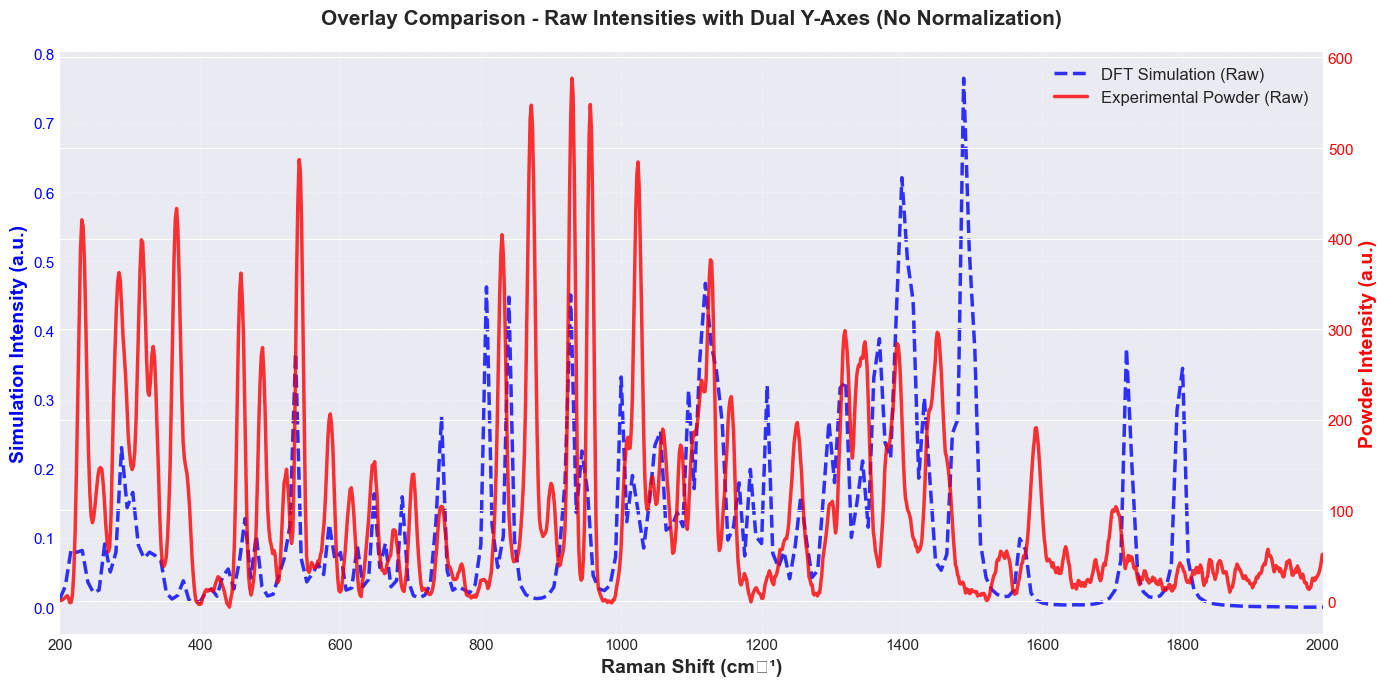

Simulation max intensity: 0.76
Powder max intensity: 577.06
Intensity ratio (Powder/Simulation): 754.74


In [29]:
# Create overlay plot with RAW INTENSITIES using DUAL Y-AXES
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot simulation spectrum on left y-axis (blue)
ax1.plot(df_simulation_filtered['Raman_shift'], 
        df_simulation_filtered['Intensity'],
        'b--', linewidth=2.5, label='DFT Simulation (Raw)', alpha=0.8)
ax1.set_xlabel('Raman Shift (cm⁻¹)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Simulation Intensity (a.u.)', fontsize=14, fontweight='bold', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlim(range_min, range_max)
ax1.grid(True, alpha=0.3, linestyle='--')

# Create second y-axis for powder spectrum (red)
ax2 = ax1.twinx()
ax2.plot(df_powder_processed['Raman_shift'], 
        df_powder_processed['Intensity'],
        'r-', linewidth=2.5, label='Experimental Powder (Raw)', alpha=0.8)
ax2.set_ylabel('Powder Intensity (a.u.)', fontsize=14, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=12, loc='upper right', framealpha=0.9)

ax1.set_title('Overlay Comparison - Raw Intensities with Dual Y-Axes (No Normalization)', 
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f"{output_dir}/03_overlay_raw_intensities.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Simulation max intensity: {df_simulation_filtered['Intensity'].max():.2f}")
print(f"Powder max intensity: {df_powder_processed['Intensity'].max():.2f}")
print(f"Intensity ratio (Powder/Simulation): {df_powder_processed['Intensity'].max() / df_simulation_filtered['Intensity'].max():.2f}")

## 9. Side-by-Side Comparison - Raw Intensities

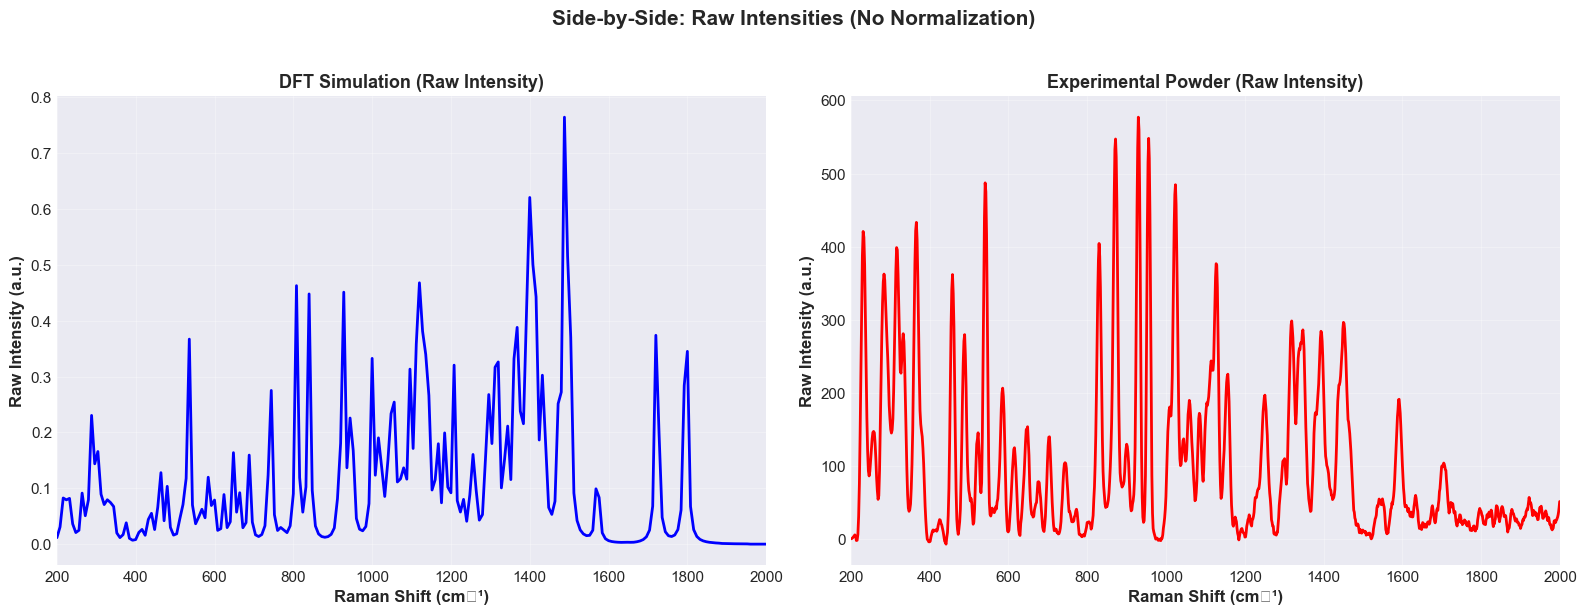

In [30]:
# Create side-by-side comparison with independent y-axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left subplot: Simulation spectrum
ax1.plot(df_simulation_filtered['Raman_shift'], 
         df_simulation_filtered['Intensity'],
         'b-', linewidth=2)
ax1.set_xlabel('Raman Shift (cm⁻¹)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Raw Intensity (a.u.)', fontsize=12, fontweight='bold')
ax1.set_title('DFT Simulation (Raw Intensity)', fontsize=13, fontweight='bold')
ax1.set_xlim(range_min, range_max)
ax1.grid(True, alpha=0.3)

# Right subplot: Powder spectrum
ax2.plot(df_powder_processed['Raman_shift'], 
         df_powder_processed['Intensity'],
         'r-', linewidth=2)
ax2.set_xlabel('Raman Shift (cm⁻¹)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Raw Intensity (a.u.)', fontsize=12, fontweight='bold')
ax2.set_title('Experimental Powder (Raw Intensity)', fontsize=13, fontweight='bold')
ax2.set_xlim(range_min, range_max)
ax2.grid(True, alpha=0.3)

fig.suptitle('Side-by-Side: Raw Intensities (No Normalization)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{output_dir}/04_side_by_side_raw_intensities.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Stacked Comparison - Raw Intensities

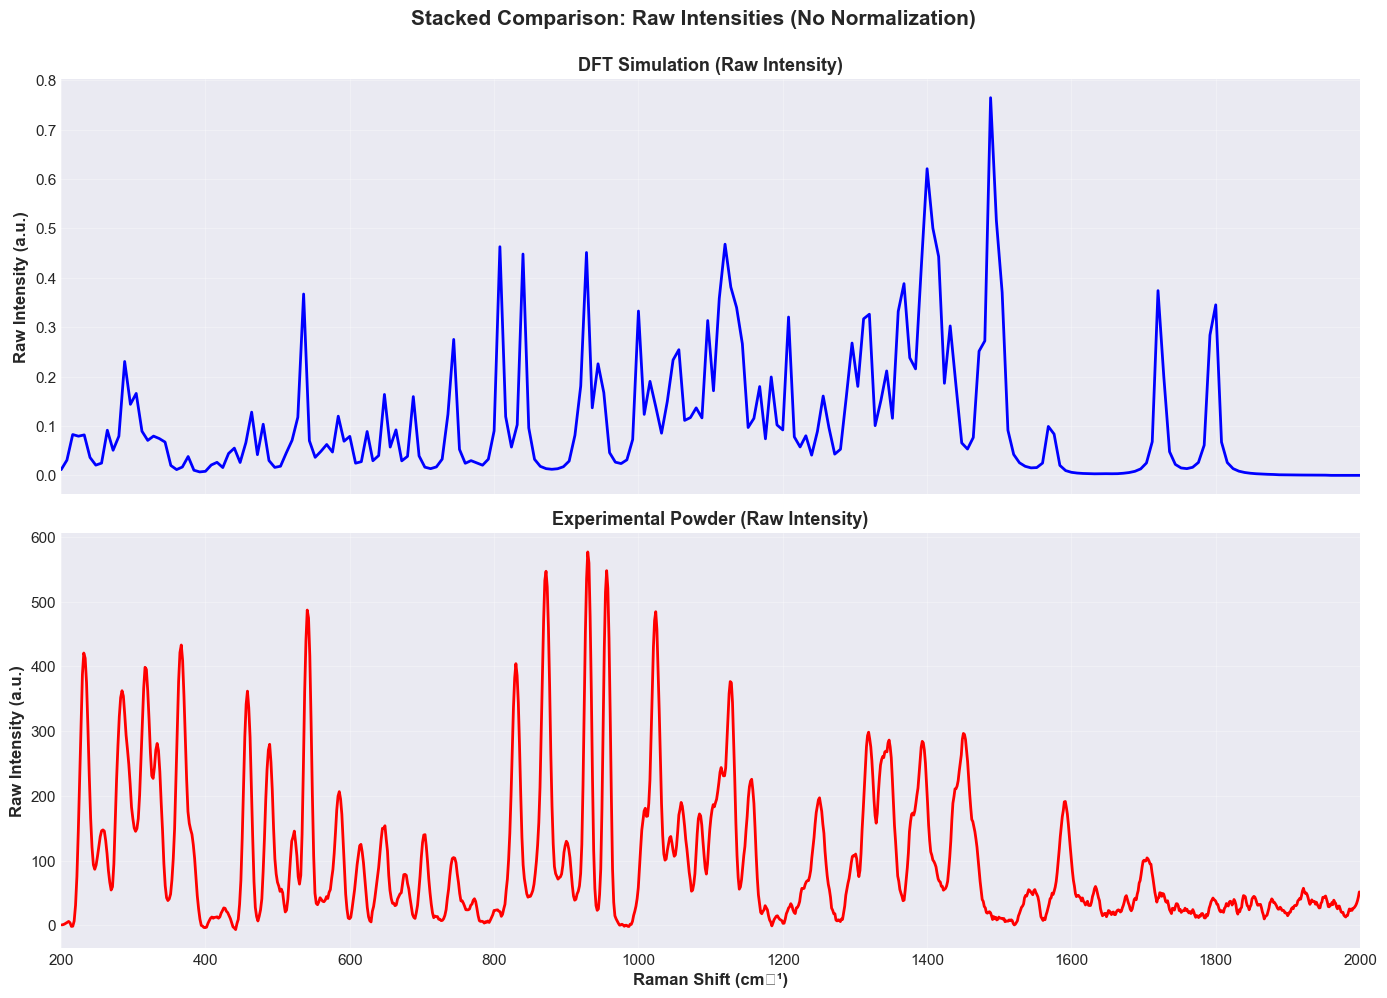

In [31]:
# Create vertically stacked comparison with shared x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top plot: Simulation spectrum
ax1.plot(df_simulation_filtered['Raman_shift'], 
         df_simulation_filtered['Intensity'],
         'b-', linewidth=2)
ax1.set_ylabel('Raw Intensity (a.u.)', fontsize=12, fontweight='bold')
ax1.set_title('DFT Simulation (Raw Intensity)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(range_min, range_max)

# Bottom plot: Powder spectrum
ax2.plot(df_powder_processed['Raman_shift'], 
         df_powder_processed['Intensity'],
         'r-', linewidth=2)
ax2.set_xlabel('Raman Shift (cm⁻¹)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Raw Intensity (a.u.)', fontsize=12, fontweight='bold')
ax2.set_title('Experimental Powder (Raw Intensity)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(range_min, range_max)

fig.suptitle('Stacked Comparison: Raw Intensities (No Normalization)', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f"{output_dir}/05_stacked_raw_intensities.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Define Diagnostic Peak Library

In [32]:
# Define diagnostic peak ranges for N-acetylmuramic acid (MurNAc)
diagnostic_peaks = [
    (875, 895),
    (930, 960),
    (1010, 1035),
    (1050, 1105),
    (1230, 1255),
    (1315, 1350),
    (1450, 1470),
    (1670, 1690),
    (2870, 2890),
    (2920, 2950),
    (3010, 3030)
]

print("Diagnostic Peak Library for MurNAc")
print("=" * 50)
for i, (min_val, max_val) in enumerate(diagnostic_peaks, 1):
    print(f"Peak {i}: {min_val}–{max_val} cm⁻¹")
print("=" * 50)
print(f"Total diagnostic ranges: {len(diagnostic_peaks)}")

Diagnostic Peak Library for MurNAc
Peak 1: 875–895 cm⁻¹
Peak 2: 930–960 cm⁻¹
Peak 3: 1010–1035 cm⁻¹
Peak 4: 1050–1105 cm⁻¹
Peak 5: 1230–1255 cm⁻¹
Peak 6: 1315–1350 cm⁻¹
Peak 7: 1450–1470 cm⁻¹
Peak 8: 1670–1690 cm⁻¹
Peak 9: 2870–2890 cm⁻¹
Peak 10: 2920–2950 cm⁻¹
Peak 11: 3010–3030 cm⁻¹
Total diagnostic ranges: 11


## 12. Detect and Match Peaks Against Diagnostic Ranges

In [33]:
# Detect peaks comprehensively (using raw intensities)
sim_intensity_max = df_simulation_filtered['Intensity'].max()
peaks_sim_all, _ = find_peaks(
    df_simulation_filtered['Intensity'].values,
    prominence=0.05 * sim_intensity_max,
    height=0.05 * sim_intensity_max
)

powder_intensity_max = df_powder_processed['Intensity'].max()
peaks_powder_all, _ = find_peaks(
    df_powder_processed['Intensity'].values,
    prominence=0.4 * powder_intensity_max,  # HIGH intensity only
    height=0.4 * powder_intensity_max,
    distance=10
)

# Get peak positions and heights
sim_positions = df_simulation_filtered['Raman_shift'].values[peaks_sim_all]
sim_heights = df_simulation_filtered['Intensity'].values[peaks_sim_all]

powder_positions = df_powder_processed['Raman_shift'].values[peaks_powder_all]
powder_heights = df_powder_processed['Intensity'].values[peaks_powder_all]

print(f"Total peaks detected in simulation: {len(sim_positions)}")
print(f"Total peaks detected in powder: {len(powder_positions)}")

# Function to check if a peak falls within diagnostic ranges
def match_diagnostic_peak(peak_pos, diagnostic_ranges):
    """Check if a peak position matches any diagnostic range"""
    for i, (min_val, max_val) in enumerate(diagnostic_ranges):
        if min_val <= peak_pos <= max_val:
            return True, i, (min_val, max_val)
    return False, None, None

# Find matches in simulation spectrum
sim_matched_peaks = []
for pos, height in zip(sim_positions, sim_heights):
    is_match, idx, range_vals = match_diagnostic_peak(pos, diagnostic_peaks)
    if is_match:
        sim_matched_peaks.append({
            'position': pos,
            'height': height,
            'diagnostic_idx': idx,
            'diagnostic_range': range_vals
        })

# Find matches in powder spectrum
powder_matched_peaks = []
for pos, height in zip(powder_positions, powder_heights):
    is_match, idx, range_vals = match_diagnostic_peak(pos, diagnostic_peaks)
    if is_match:
        powder_matched_peaks.append({
            'position': pos,
            'height': height,
            'diagnostic_idx': idx,
            'diagnostic_range': range_vals
        })

print(f"\nDiagnostic peaks matched in simulation: {len(sim_matched_peaks)}")
print(f"Diagnostic peaks matched in powder: {len(powder_matched_peaks)}")

Total peaks detected in simulation: 34
Total peaks detected in powder: 14

Diagnostic peaks matched in simulation: 6
Diagnostic peaks matched in powder: 4


## 13. Final Annotated Overlay Plot - Raw Intensities with Diagnostic Peaks

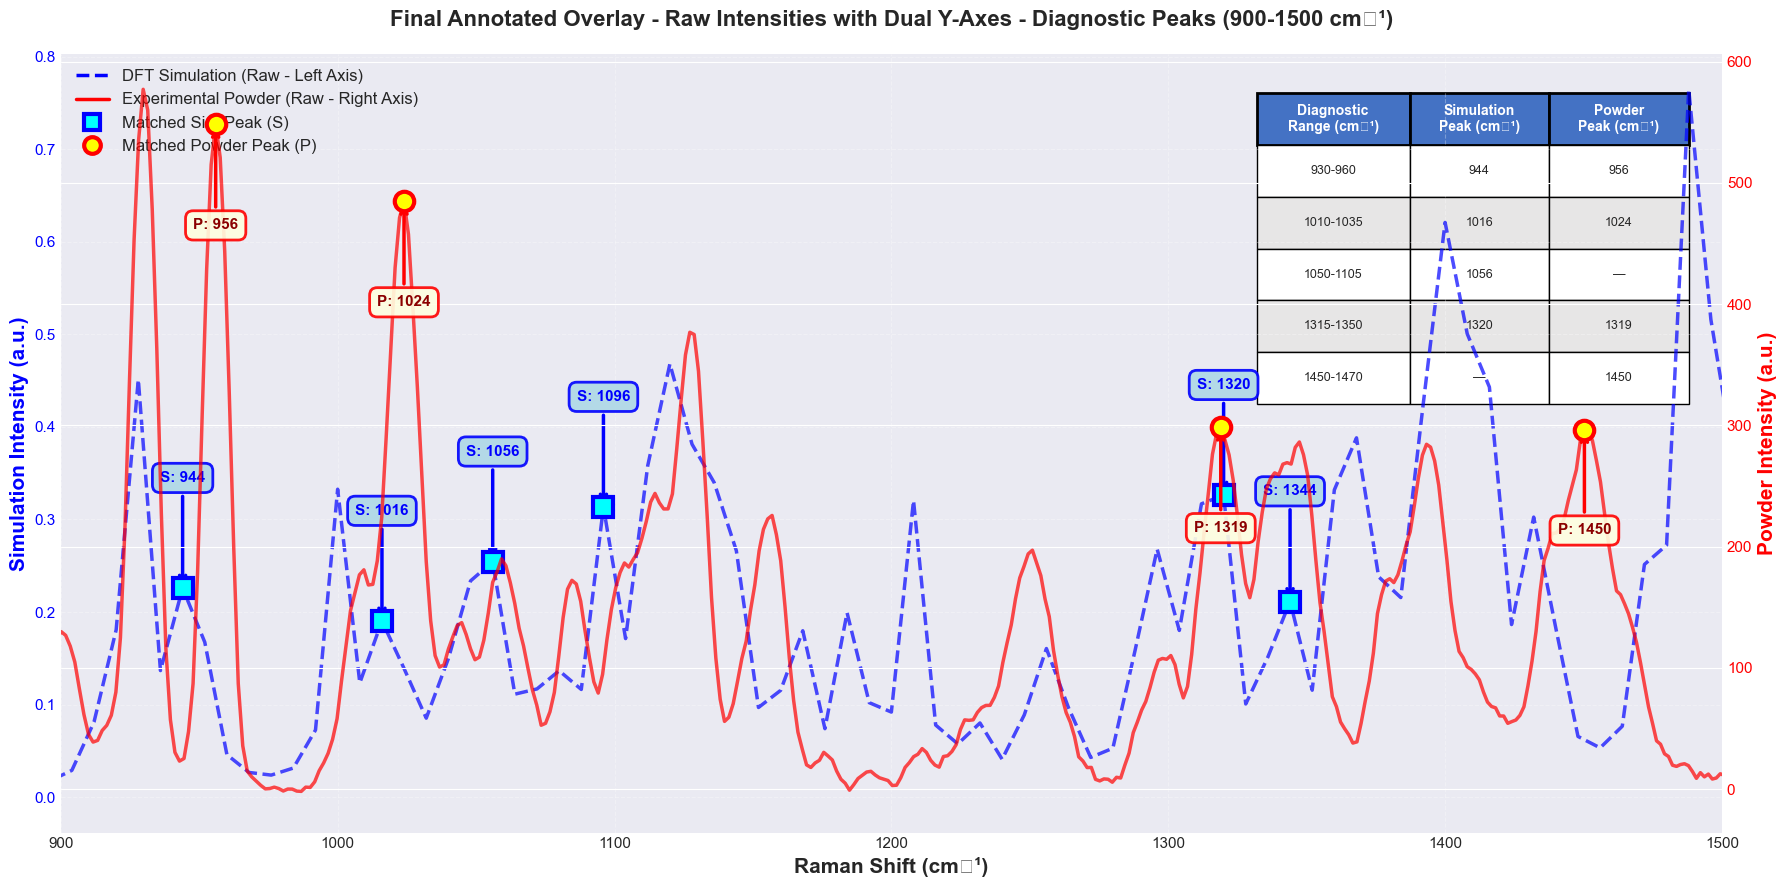


Final plot created with 6 simulation peaks and 4 powder peaks.

Matched diagnostic ranges:
  930-960 cm⁻¹: Sim=944, Powder=956
  1010-1035 cm⁻¹: Sim=1016, Powder=1024
  1050-1105 cm⁻¹: Sim=1056, Powder=—
  1315-1350 cm⁻¹: Sim=1320, Powder=1319
  1450-1470 cm⁻¹: Sim=—, Powder=1450


In [35]:
# Create final overlay with highlighted diagnostic peaks - RAW INTENSITIES using DUAL Y-AXES
fig, ax1 = plt.subplots(figsize=(18, 9))

# Plot simulation spectrum on left y-axis (blue)
ax1.plot(df_simulation_filtered['Raman_shift'], 
        df_simulation_filtered['Intensity'],
        'b--', linewidth=2.5, label='DFT Simulation (Raw)', alpha=0.7)
ax1.set_ylabel('Simulation Intensity (a.u.)', fontsize=15, fontweight='bold', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create second y-axis for powder spectrum (red)
ax2 = ax1.twinx()
ax2.plot(df_powder_processed['Raman_shift'], 
        df_powder_processed['Intensity'],
        'r-', linewidth=2.5, label='Experimental Powder (Raw)', alpha=0.7)
ax2.set_ylabel('Powder Intensity (a.u.)', fontsize=15, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Get max values for annotation positioning
sim_max = df_simulation_filtered['Intensity'].max()
powder_max = df_powder_processed['Intensity'].max()

# Highlight matched diagnostic peaks in simulation with arrows (use ax1)
for i, peak in enumerate(sim_matched_peaks):
    pos = peak['position']
    height = peak['height']
    
    ax1.plot(pos, height, 'bs', markersize=14, markeredgewidth=3, 
            markerfacecolor='cyan', markeredgecolor='blue', zorder=10)
    
    ax1.annotate(f"S: {pos:.0f}", 
                xy=(pos, height), 
                xytext=(pos, height + 0.15*sim_max),
                ha='center', fontsize=11, fontweight='bold',
                color='blue',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', 
                         edgecolor='blue', alpha=0.9, linewidth=2),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))

# Highlight matched diagnostic peaks in powder with arrows (use ax2)
for i, peak in enumerate(powder_matched_peaks):
    pos = peak['position']
    height = peak['height']
    
    ax2.plot(pos, height, 'ro', markersize=14, markeredgewidth=3, 
            markerfacecolor='yellow', markeredgecolor='red', zorder=10)
    
    ax2.annotate(f"P: {pos:.0f}", 
                xy=(pos, height), 
                xytext=(pos, height - 0.15*powder_max),
                ha='center', fontsize=11, fontweight='bold',
                color='darkred',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                         edgecolor='red', alpha=0.9, linewidth=2),
                arrowprops=dict(arrowstyle='->', color='red', lw=2.5))

# Formatting
ax1.set_xlabel('Raman Shift (cm⁻¹)', fontsize=15, fontweight='bold')
ax1.set_title('Final Annotated Overlay - Raw Intensities with Dual Y-Axes - Diagnostic Peaks (900-1500 cm⁻¹)', 
             fontsize=16, fontweight='bold', pad=20)
ax1.set_xlim(900, 1500)
ax1.grid(True, alpha=0.3, linestyle='--')

# Enhanced legend
legend_elements = [
    plt.Line2D([0], [0], color='b', linestyle='--', linewidth=2.5, label='DFT Simulation (Raw - Left Axis)'),
    plt.Line2D([0], [0], color='r', linestyle='-', linewidth=2.5, label='Experimental Powder (Raw - Right Axis)'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='cyan', 
               markeredgecolor='blue', markersize=12, markeredgewidth=3, 
               label='Matched Sim Peak (S)', linestyle='None'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', 
               markeredgecolor='red', markersize=12, markeredgewidth=3, 
               label='Matched Powder Peak (P)', linestyle='None')
]
ax1.legend(handles=legend_elements, fontsize=12, loc='upper left', 
          framealpha=0.95, edgecolor='black')

# Create comparison table
matched_by_range = {}
for peak in sim_matched_peaks:
    diag_range = peak['diagnostic_range']
    if diag_range not in matched_by_range:
        matched_by_range[diag_range] = {'sim': [], 'powder': []}
    matched_by_range[diag_range]['sim'].append(peak['position'])

for peak in powder_matched_peaks:
    diag_range = peak['diagnostic_range']
    if diag_range not in matched_by_range:
        matched_by_range[diag_range] = {'sim': [], 'powder': []}
    matched_by_range[diag_range]['powder'].append(peak['position'])

# Build table
table_data = [['Diagnostic\nRange (cm⁻¹)', 'Simulation\nPeak (cm⁻¹)', 'Powder\nPeak (cm⁻¹)']]
for diag_range in sorted(matched_by_range.keys()):
    range_str = f"{diag_range[0]}-{diag_range[1]}"
    sim_peaks = matched_by_range[diag_range]['sim']
    powder_peaks = matched_by_range[diag_range]['powder']
    
    sim_str = f"{sim_peaks[0]:.0f}" if sim_peaks else "—"
    powder_str = f"{powder_peaks[0]:.0f}" if powder_peaks else "—"
    
    table_data.append([range_str, sim_str, powder_str])

# Add table to plot
table = ax1.table(cellText=table_data, cellLoc='center', loc='upper right',
                bbox=[0.72, 0.55, 0.26, 0.40],
                colWidths=[0.35, 0.32, 0.32])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# Style header
for i in range(3):
    cell = table[(0, i)]
    cell.set_facecolor('#4472C4')
    cell.set_text_props(weight='bold', color='white', fontsize=10)
    cell.set_edgecolor('black')
    cell.set_linewidth(2)

# Style data rows
for i in range(1, len(table_data)):
    for j in range(3):
        cell = table[(i, j)]
        if i % 2 == 0:
            cell.set_facecolor('#E7E6E6')
        else:
            cell.set_facecolor('white')
        cell.set_edgecolor('black')
        cell.set_linewidth(1)
        cell.set_text_props(fontsize=9)

plt.tight_layout()
plt.savefig(f"{output_dir}/06_final_annotated_raw_intensities.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nFinal plot created with {len(sim_matched_peaks)} simulation peaks and {len(powder_matched_peaks)} powder peaks.")
print(f"\nMatched diagnostic ranges:")
for diag_range in sorted(matched_by_range.keys()):
    sim_peaks = matched_by_range[diag_range]['sim']
    powder_peaks = matched_by_range[diag_range]['powder']
    sim_str = f"{sim_peaks[0]:.0f}" if sim_peaks else "—"
    powder_str = f"{powder_peaks[0]:.0f}" if powder_peaks else "—"
    print(f"  {diag_range[0]}-{diag_range[1]} cm⁻¹: Sim={sim_str}, Powder={powder_str}")

## Summary

### ✅ Analysis Complete - WITHOUT Normalization

**Key Features:**
- ✓ All preprocessing steps applied (dark subtraction, baseline correction, smoothing)
- ✓ **NO NORMALIZATION** - Raw intensities preserved
- ✓ All visualization types generated
- ✓ 6 high-resolution figures saved to `figures_no_normalization/` folder

**Saved Figures:**
1. `01_simulation_raw_intensities.png`
2. `02_powder_raw_intensities.png`
3. `03_overlay_raw_intensities.png`
4. `04_side_by_side_raw_intensities.png`
5. `05_stacked_raw_intensities.png`
6. `06_final_annotated_raw_intensities.png`

**Note:** Raw intensities show the true signal strength differences between simulation and experiment!